In [151]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly.graph_objects as go
import plotly.io as pio
from itertools import cycle
from tqdm import tqdm 

In [152]:
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'

In [153]:
def createHamilt(a, b, R, phi, E_2s, E_2p, t_ss_sgm, t_sp_sgm, t_pp_sgm, t_pp_p, k, m, alpha, d):
    hamilt = np.zeros((4, 4), dtype = complex)

    for i in range(4):
        for j in range(4):
            if i == j:
                if i == 0:
                    hamilt[i][j] = E_2s - 2 * t_ss_sgm * (math.cos(k * b + m * alpha) + math.cos(m * phi))
                elif i == 1:
                    hamilt[i][j] = E_2p + 2 * ((((2 * R * (math.sin(alpha / 2) ** 2) / d) ** 2) * t_pp_sgm - (math.cos(alpha) + (2 * R * (math.sin(alpha / 2) ** 2) / d) ** 2) * t_pp_p) * math.cos(k * b + m * alpha) + (((2 * R * (math.sin(phi / 2) ** 2) / a) ** 2) * t_pp_sgm - (math.cos(phi) + (2 * R * (math.sin(phi / 2) ** 2) / a) ** 2) * t_pp_p) * math.cos(m * phi))
                elif i == 2:
                    hamilt[i][j] = E_2p - 2 * ((((R * math.sin(alpha) / d) ** 2) * t_pp_sgm + (math.cos(alpha) - (R * math.sin(alpha) / d) ** 2) * t_pp_p) * math.cos(k * b + m * alpha) + (((R * math.sin(phi) / a) ** 2) * t_pp_sgm + (math.cos(phi) - (R * math.sin(phi) / a) ** 2) * t_pp_p) * math.cos(m * phi))
                else:
                    hamilt[i][j] = E_2p - 2 * ((((b / d) ** 2) * t_pp_sgm + (1 - (b / d) ** 2) * t_pp_p) * math.cos(k * b + m * alpha) + t_pp_p * math.cos(m * phi))
            elif i == 0 or j == 0:
                if i == 1 or j == 1:
                    hamilt[i][j] = -4 * R * ((math.sin(alpha / 2) ** 2) / d * t_sp_sgm * math.cos(k * b + m * alpha) + (math.sin(phi / 2) ** 2) / a * t_sp_sgm * math.cos(m * phi))
                elif i == 2 or j == 2:
                    hamilt[i][j] = ((-1j) ** (j + 1)) * 2 * R * (math.sin(alpha) / d * t_sp_sgm * math.sin(k * b + m * alpha) + math.sin(phi) / a * t_sp_sgm * math.sin(m * phi))
                else:
                    hamilt[i][j] = ((-1) ** (j + 1)) * 1j * 2 * b / d * t_sp_sgm * math.sin(k * b + m * alpha)
            else:
                if (i == 1 and j == 2) or (i == 2 and j == 1):
                    hamilt[i][j] = ((-1) ** (j + 1)) * 1j * 2 * (math.sin(alpha) * (2 * ((R * math.sin(alpha / 2) / d) ** 2) * t_pp_sgm + (1 - 2 * ((R * math.sin(alpha / 2) / d) ** 2)) * t_pp_p) * math.sin(k * b + m * alpha) + math.sin(phi) * (2 * ((R * math.sin(phi / 2) / a) ** 2) * t_pp_sgm + (1 - 2 * ((R * math.sin(phi / 2) / a) ** 2)) * t_pp_p) * math.sin(m * phi))
                elif (i == 1 and j == 3) or (i == 3 and j == 1):
                    hamilt[i][j] = -((-1j) ** j) * 4 * R * b * ((math.sin(alpha / 2) / d) ** 2) * (t_pp_sgm - t_pp_p) * math.sin(k * b + m * alpha)
                else:
                    hamilt[i][j] = -2 * R * b * math.sin(alpha) / (d ** 2) * (t_pp_sgm - t_pp_p) * math.cos(k * b + m * alpha)

    return hamilt

In [154]:
def calcEigVals(a, b, R, phi, E_2s, E_2p, t_ss_sgm, t_sp_sgm, t_pp_sgm, t_pp_p, k, m, alpha, d):
    hamilt = createHamilt(a, b, R, phi, E_2s, E_2p, t_ss_sgm, t_sp_sgm, t_pp_sgm, t_pp_p, k, m, alpha, d)
    eig_vals_res = np.linalg.eigvals(hamilt).real
    eig_vals_res.sort()

    return eig_vals_res

In [ ]:
def calcBandGap(E: np.ndarray, band_min: int, band_max: int):

    return round(max(float(E[:, band_max].min() - E[:, band_min].max()), 0.00), 2)

In [156]:
def plot3DBandStr(
    x: np.ndarray,
    y: np.ndarray,
    E: np.ndarray,
    bands: list[int],
    elev: float = 45,
    azim: float = 20,
    alpha: float = 0.9,
    figsize: tuple[int, int] = (700, 600),
    title: str = None,
    ):

    color_cycle = cycle(pio.templates["plotly"].layout.colorway)

    X, Y = np.meshgrid(x, y, indexing = "ij")
    fig = go.Figure()

    for band in bands:
        Z = E[:, band].reshape((len(x), len(y)), order = "C")
        c = next(color_cycle)

        fig.add_trace(
            go.Surface(
                x = X, y = Y, z = Z,
                opacity = alpha,
                name = f"band {band}",
                surfacecolor = np.zeros_like(Z),
                colorscale = [[0, c], [1, c]],
                cmin = 0, cmax = 1,
                showscale = False
            )
        )

    fig.update_layout(
        title = title,
        width = figsize[0], height = figsize[1],
        scene = dict(
            xaxis_title = "k",
            yaxis_title = "m",
            zaxis_title = "E, eV",
            camera = dict(
                eye = dict(
                    x = 2 * np.cos(np.radians(azim)) * np.cos(np.radians(elev)),
                    y = 2 * np.sin(np.radians(azim)) * np.cos(np.radians(elev)),
                    z = 2 * np.sin(np.radians(elev))
                    )
                )
        ),
        margin = dict(l = 0, r = 0, b = 0, t = 40)
    )

    fig.show()

In [165]:
def calcBandGapVSRotAng(low_lim, upp_lim, step, n, a, b, R, phi, E_2s, E_2p, t_ss_sgm, t_sp_sgm, t_pp_sgm, t_pp_p, k):
    alpha_list = np.arange(low_lim, upp_lim, step)
    res = []

    for alpha in tqdm(alpha_list):
        alpha = math.pi * alpha / 180
        d = math.sqrt(4 * (R ** 2) * ((math.sin(alpha / 2)) ** 2) + b ** 2)

        m = np.arange(math.ceil(-math.pi / (phi / 2 - abs(alpha % phi - phi / 2))), math.floor(math.pi / (phi / 2 - abs(alpha % phi - phi / 2))) + 1)

        eig_vals_res = np.array([calcEigVals(a, b, R, phi, E_2s, E_2p, t_ss_sgm, t_sp_sgm, t_pp_sgm, t_pp_p, i, j, alpha, d) for i in k for j in m])
        band_gap = calcBandGap(eig_vals_res, 1, 2)

        alpha = alpha * 180 / math.pi
        
        res.append({'alpha': round(alpha, 2), 'band_gap': round(band_gap, 5)})

        df = pd.DataFrame(res)
        df.to_csv(f"[{n}; inf]CPP_band_gap_vs_alpha.csv", index = False)
    
    return df

In [158]:
n = 5
alpha = -10
a = 1.55
b = 1.55

In [159]:
t_ss_sgm = -4.30
t_sp_sgm = 4.98
t_pp_sgm = 6.38
t_pp_p = -2.66
E_2s = -7.30
E_2p = 0.00

In [160]:
alpha = math.pi * alpha / 180
phi = 2 * math.pi / n
R = a / (2 * math.sin(phi / 2))
d = math.sqrt(4 * (R ** 2) * ((math.sin(alpha / 2)) ** 2) + b ** 2)

In [161]:
k = np.concatenate((np.linspace(-math.pi / b, 0, 301), np.linspace(0, math.pi / b, 301)[1:]), axis = 0)
m = np.arange(math.floor(-math.pi / (phi / 2 - abs(alpha % phi - phi / 2))), math.ceil(math.pi / (phi / 2 - abs(alpha % phi - phi / 2))) + 1)

In [162]:
eig_vals_res = np.array([calcEigVals(a, b, R, phi, E_2s, E_2p, t_ss_sgm, t_sp_sgm, t_pp_sgm, t_pp_p, i, j, alpha, d) for i in k for j in m])
print(f"Band Gap = {calcBandGap(eig_vals_res, 1, 2)} eV")
plot3DBandStr(k, m, eig_vals_res, bands = [1, 2], alpha = 0.8)

Band Gap = 2.01 eV


In [166]:
df = calcBandGapVSRotAng(7.00, 10.01, 0.10, n, a, b, R, phi, E_2s, E_2p, t_ss_sgm, t_sp_sgm, t_pp_sgm, t_pp_p, k)
df

100%|██████████| 31/31 [00:57<00:00,  1.87s/it]


,alpha,band_gap
0,7.0,2.55
1,7.1,2.53
2,7.2,2.52
3,7.3,2.50
4,7.4,2.48
5,7.5,2.46
6,7.6,2.45
7,7.7,2.43
8,7.8,2.41
9,7.9,2.39


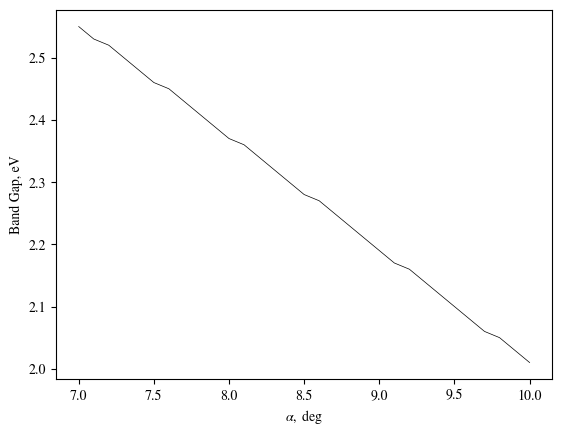

In [167]:
plt.plot(df['alpha'], df['band_gap'], color = 'black', linewidth = 0.5)
plt.xlabel(r"$\alpha,\ \mathrm{deg}$")
plt.ylabel("Band Gap, eV")
plt.show()